# Assessment to selection

In [1]:
from pathlib import Path

from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
    evaluate_selection
)

In [26]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [27]:
# Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(price_csv=PRICE_CSV, ratio_csv=RATIO_CSV, data_root=DATA_DIR)
prices = assessment.prices

In [4]:
date = '2025-09-01'
features = assessment.assess(date)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


In [5]:
threshold = LongThresholdFilter()
threshold.trace(features)

,step,feature,operator,threshold,remaining
0,0,initial_universe,,<NA>,200
1,1,per_hist_pct,<=,80.0,107
2,2,eps_growth_pct,>=,20.0,78
3,3,momentum_12m_pct,>=,20.0,64


In [6]:
eligible = threshold.select(features)

#candidates = LongEqualFeatureScore(top_n=20)
candidates = LongEqualGroupScore(top_n=20)

selected = candidates.select(features, tickers=eligible['ticker'])
selected.head()

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,443060,2025-09-01,204000.0,17402.0,38.46,11.72,5304.0,1.54,3150.0,37.300,...,89.847716,0.427518,-0.356853,52.261307,70.351759,65.775291,86.666667,87.853151,80.098369,1
1,012450,2025-09-01,916000.0,108184.0,19.91,8.47,46002.0,0.38,3500.0,19.335,...,95.431472,0.497394,-0.329328,68.341709,62.311558,42.614606,96.052915,89.634928,76.100816,2
2,267260,2025-09-01,487000.0,41725.0,34.95,11.67,13935.0,1.10,5350.0,35.250,...,79.695431,0.475213,-0.404494,64.321608,81.909548,56.490642,90.492232,80.504281,75.829052,3
3,062040,2025-09-01,106200.0,14292.0,33.86,7.43,3136.0,0.40,420.0,36.685,...,93.908629,0.590233,-0.454657,84.924623,88.944724,45.980417,90.655284,90.388658,75.674786,4
4,006800,2025-09-01,18758.0,20662.0,12.19,0.91,1545.0,1.33,250.0,11.860,...,91.370558,0.539227,-0.241348,77.889447,31.155779,47.782559,83.665590,94.422653,75.290267,5


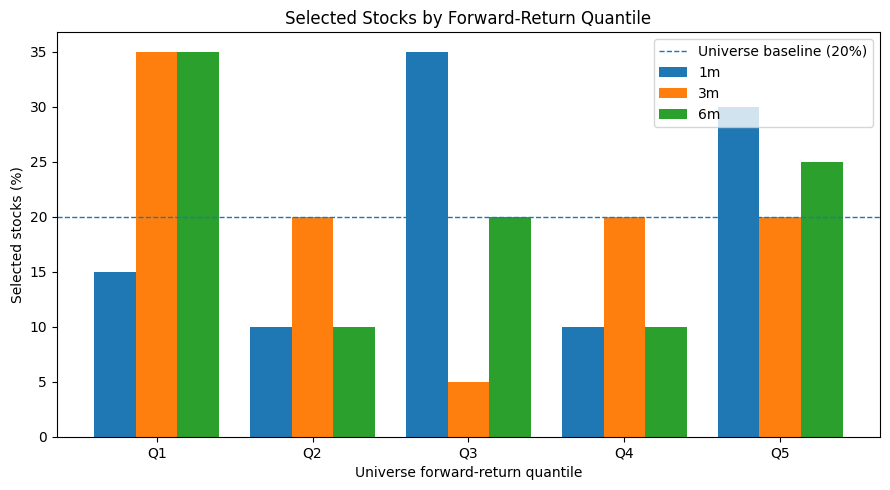

In [7]:
kw = dict(
    horizons = [1,3,6],
    plot = 'distribution',
    universe = features, 
    prices = prices
)
_ = evaluate_selection(selected, **kw)

# Recipes

In [59]:
from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongThresholdFilter as LongFilter, 
    LongEqualFeatureScore as LongFeature,
    LongEqualGroupScore as LongGroup
)
from stocksift.recipes import apply_selection, evaluate_recipe

In [60]:
DATA_DIR = '../pf/data'

dates = ['260904', '260814']
PRICE_CSV = [f"kospi200_prices_{x}.csv" for x in dates]
RATIO_CSV = [f"kospi200_ratios_{x}.csv" for x in dates]

In [61]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(
    price_csv=PRICE_CSV, 
    ratio_csv=RATIO_CSV, 
    data_root=DATA_DIR
)

INFO: kospi200_ratios_260814.csv -> kospi200_ratios_260904.csv: 200 common tickers merged successfully.


*Rule variants*

In [46]:
ft1 = [
    ("per_hist_pct", "<=", 50.0),
    ("eps_growth_pct", ">=", 50.0),
    ("momentum_12m_pct", ">=", 50.0),
]

ft2 = [
    ("per_hist_pct", "<=", 80.0),
    ("eps_growth_pct", ">=", 20.0),
    ("momentum_12m_pct", ">=", 20.0),
]

v1 = {
    "per_hist_pct": "lower",
    "pbr_hist_pct": "lower",
}

v2 = {
    "per_expansion_pct": "lower",
    "pbr_expansion_pct": "lower",
}


f1 =  {
    "eps_growth_pct": "higher",
    "bps_growth_pct": "higher",
    #"dps_growth_pct": "higher",
}

m1 = {
    "momentum_6m_pct": "higher",
    #"momentum_12m_pct": "higher",
}

In [47]:
n = 20

#policies = [LongFilter(ft2)]
#policies = [LongFeature(f1, top_n=n)]
#policies = [LongFeature(v2, top_n=n)]
#policies = [LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft1)]
##policies = [LongFeature(v1, top_n=n)]

#policies = [LongFilter(ft2), LongFeature(f1, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(v2, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft2), LongFeature(v1, top_n=n)]

In [48]:
n = 10

make_group = lambda v, f, m=None: LongGroup({
    'valuation': v, 'fundamentals': f, **({} if m is None else {'momentum': m}),
}, top_n=n)

policies = [LongFilter(ft2), make_group(v2, f1, m1)]
#policies = [LongFilter(ft2), make_group(v1, f1, m1)]
#policies = [LongFilter(ft2), make_group(v2, f1)]
#policies = [LongFilter(ft2), make_group(v1, f1)]
#policies = [make_group(v2, f1, m1)]
#policies = [make_group(v1, f1)]
#policies = [make_group(v2, f1)]
#policies = [LongFilter(ft1), make_group(v2, f1, m1)]

INFO: 13 months of history available; approximately 0 months are usable for historical recipe evaluation or trajectory analysis.
Selected: 199 -> 64 -> 10


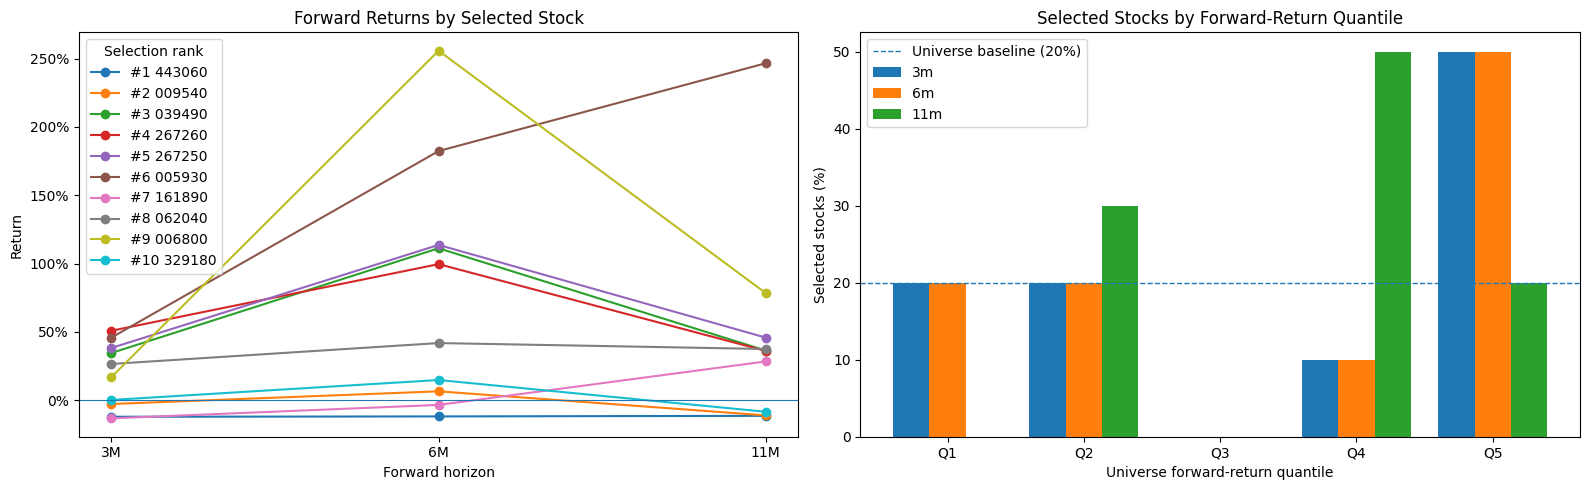

In [49]:
kw = dict(
    as_of = '2025-09-01',
    policies = policies,
    #horizons = [1,3,6],
    horizons = [3,6,11],

)

_ = evaluate_recipe(
    assessment, **kw,
    plot='both'#plot='distribution',
)

In [8]:
result = evaluate_recipe(
    assessment, **kw,
    result="summary",
)
result

Selected: 200 -> 64 -> 10


,horizon,selected_count,universe_count,selected_mean_return,universe_mean_return,mean_excess_return,selected_median_return,universe_median_return,median_excess_return,top_quantile_hit_rate,bottom_quantile_hit_rate,quantile_baseline_rate,selected_mean_percentile
0,1m,10,200,0.106432,0.027256,0.079177,0.096003,0.007716,0.088287,0.5,0.0,0.2,76.475
1,3m,10,200,0.185136,0.124728,0.060408,0.217602,0.070458,0.147144,0.5,0.2,0.2,58.100
2,6m,10,200,0.810380,0.440851,0.369529,0.707137,0.297526,0.409612,0.5,0.2,0.2,60.100


In [16]:
#result.to_dict()

# Trajectory

In [1]:
from stocksift.assessment import StockAssessment
from stocksift.recipes import selection_trajectory
from stocksift.widgets import long_selection_widget
from stocksift.charts import browse_price_chart, browse_price_comparison
from stocksift.naver import fetch_naver_ohlcv

In [2]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260904.csv"
RATIO_CSV = "kospi200_ratios_260904.csv"
TICKER_NAME_CSV = 'kospi200_const_20260828.csv'

In [3]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(
    price_csv=PRICE_CSV, 
    ratio_csv=RATIO_CSV, 
    ticker_name_csv=TICKER_NAME_CSV, 
    data_root=DATA_DIR
)

In [4]:
#features = assessment.assess()
features = None

In [5]:
controls = long_selection_widget(features)

*selected for the latest date; features must be given*

In [6]:
#controls.select() if features is not None else None

In [6]:
kw = dict(
    freq = 10, periods = 4,
    policies = controls.policies
)

selected = selection_trajectory(assessment, style=True, **kw)
selected

Selection trajectory:   0%|          | 0/4 [00:00<?, ?it/s]

,2026-07-23,2026-08-06,2026-08-21,2026-09-04
rank,,,,
1,483650,483650,007660,007660
2,002380,002380,483650,483650
3,278470,278470,002380,002380
4,082740,010130,278470,278470
5,007660,329180,062040,062040
6,066570,298040,192820,082740
7,071050,066570,003230,036570
8,030200,009540,010130,298040
9,010130,036570,066570,003230


*get close price only*

In [7]:
#prices = assessment.prices

*get ohlcv from naver finance*

In [8]:
n = -1 # the last date of trajectories

tickers = selected.data.iloc[:,n].to_list()

prices = fetch_naver_ohlcv(
    tickers,
    start="2025-01-01",
)

Fetching OHLCV:   0%|          | 0/10 [00:00<?, ?ticker/s]

In [9]:
kw = dict(
    ticker_names = assessment.ticker_names
)

browse_price_chart(prices, tickers, freq='W', **kw)

In [12]:
browse_price_comparison(prices, tickers, **kw)

# testing

In [1]:
from pathlib import Path

from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
    evaluate_selection
)

In [2]:
DATA_DIR = 'del'
PRICE_CSV = "kospi200_prices_*.csv"

In [3]:
RATIO_CSV = "kospi200_ratios_*.csv"

In [4]:
# Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(price_csv=PRICE_CSV, ratio_csv=RATIO_CSV, data_root=DATA_DIR)
prices = assessment.prices

INFO: matched 2 files:
  - kospi200_prices_260814.csv
  - kospi200_prices_260904.csv
INFO: matched 2 files:
  - kospi200_ratios_260814.csv
  - kospi200_ratios_260904.csv
INFO: kospi200_ratios_260814.csv -> kospi200_ratios_260904.csv: 200 common tickers merged successfully.


In [7]:
assessment.consolidation_failures['prices']

[{'ticker': '000880',
  'previous_file': 'kospi200_prices_260814.csv',
  'new_file': 'kospi200_prices_260904.csv',
  'file_old_end': '2026-08-14',
  'file_new_start': '2023-09-04',
  'file_overlap_dates': 716,
  'ticker_old_end': '2026-08-14',
  'ticker_new_start': '2023-09-04',
  'ticker_overlap_dates': 716,
  'min_check_dates': 10,
  'max_check_dates': 20,
  'tolerance': 0.0,
  'reason': 'tolerance',
  'checked_dates': 20,
  'compared_values': 20,
  'failed_values': 20,
  'failed_ratio': 1.0,
  'failed_columns': {'price': 20}}]

In [43]:
#date = '2026-02-01'
date = None
features = assessment.assess(date)
print(f"Assessment universe: {len(features)}")

INFO: 19 months of history available; approximately 6 months are usable for historical recipe evaluation or trajectory analysis.
Assessment universe: 200


In [47]:
features

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,dps_growth_12m,dps_growth_pct,momentum_6m,momentum_12m,momentum_6m_pct,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct
0,000080,2026-08-14,15850.0,16066,26.59,0.99,596,4.42,700,25.695,...,0.000000,26.190476,-0.125276,-0.186762,47.5,13.567839,0.306024,-0.269093,2.0,9.5
1,000100,2026-08-14,83700.0,30855,32.20,2.71,2599,0.72,600,28.625,...,0.200000,64.285714,-0.230699,-0.268357,23.5,8.040201,0.504443,-0.468800,23.5,58.5
2,000120,2026-08-14,77200.0,207860,6.80,0.37,11347,1.04,800,6.590,...,0.000000,26.190476,-0.450142,-0.070999,2.0,24.623116,0.435319,-0.514756,13.0,71.0
3,000150,2026-08-14,1276000.0,87399,301.65,14.60,4230,0.31,4000,282.270,...,1.000000,91.071429,0.354565,1.299099,89.0,90.452261,1.249294,-0.591466,95.5,85.5
4,000210,2026-08-14,51900.0,177828,0.00,0.29,0,0.00,0,16.540,...,-1.000000,2.380952,0.054878,0.335907,72.0,61.306533,0.779254,-0.464193,66.5,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,450080,2026-08-14,39900.0,15125,115.65,2.64,345,0.00,0,99.640,...,NaN,NaN,-0.393617,-0.293805,5.0,7.035176,0.888672,-0.668981,76.0,96.5
196,454910,2026-08-14,79200.0,5378,0.00,14.73,0,0.00,0,NaN,...,NaN,NaN,-0.208791,0.249211,27.0,55.778894,1.161729,-0.667666,92.5,96.0
197,456040,2026-08-14,80900.0,125846,0.00,0.64,0,0.00,0,8.975,...,-1.000000,2.380952,-0.064740,0.375850,58.5,65.326633,0.826784,-0.586667,70.5,82.5
198,457190,2026-08-14,68200.0,4398,2623.08,15.51,26,0.00,0,2217.305,...,NaN,NaN,-0.315948,0.403292,11.0,66.331658,0.814663,-0.635665,69.5,93.0


In [44]:
threshold = LongThresholdFilter()
#threshold.trace(features)

In [45]:
eligible = threshold.select(features)

#candidates = LongEqualFeatureScore(top_n=20)
candidates = LongEqualGroupScore(top_n=20)

selected = candidates.select(features, tickers=eligible['ticker'])
#selected.head()

# testing

In [1]:
from pathlib import Path

from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
    evaluate_selection
)

In [2]:
DATA_DIR = 'del'
PRICE_CSV = "kospi200_prices_*.csv"

In [3]:
RATIO_CSV = "kospi200_ratios_*.csv"

In [4]:
# Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(price_csv=PRICE_CSV, ratio_csv=RATIO_CSV, data_root=DATA_DIR)
prices = assessment.prices

INFO: matched 2 files:
  - kospi200_prices_260814.csv
  - kospi200_prices_260904.csv
INFO: matched 2 files:
  - kospi200_ratios_260814.csv
  - kospi200_ratios_260904.csv
INFO: kospi200_ratios_260814.csv -> kospi200_ratios_260904.csv: 200 common tickers merged successfully.


In [5]:
from stocksift.recipes import LONG_FILTER_REGISTRY

features = assessment.assess("2026-09-01")

for key, spec in LONG_FILTER_REGISTRY.items():
    policy = spec["factory"]()

    print(
        key,
        len(policy.select(features)),
        "/",
        len(features),
    )

    display(policy.trace(features))

INFO: 25 months of history available; approximately 12 months are usable for historical recipe evaluation or trajectory analysis.
mild 115 / 201


,step,feature,operator,threshold,remaining
0,0,initial_universe,,<NA>,201
1,1,per_hist_pct,<=,90.0,148
2,2,eps_growth_pct,>=,10.0,126
3,3,momentum_12m_pct,>=,10.0,115


strict 86 / 201


,step,feature,operator,threshold,remaining
0,0,initial_universe,,<NA>,201
1,1,per_hist_pct,<=,80.0,126
2,2,eps_growth_pct,>=,20.0,104
3,3,momentum_12m_pct,>=,20.0,86


In [7]:
from stocksift.recipes import (
    apply_selection,
    build_long_selection,
)

policies = build_long_selection(
    filter="mild",
    strategy="momentum",
    top_n=20,
)

selected = apply_selection(features, policies)
selected

Selected: 201 -> 115 -> 20


,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,278470,2026-09-01,432500.0,11910,55.70,36.31,7765,1.18,5090,50.675,...,86.934673,0.674082,-0.313725,53.5,18.905473,55.221645,90.558213,89.717337,82.986374,1
1,402340,2026-09-01,1067000.0,209564,15.99,5.09,66713,0.00,0,15.890,...,99.497487,1.340340,-0.594416,99.0,86.069652,21.687834,90.358419,97.998744,81.208497,2
2,000660,2026-09-01,1693000.0,171751,27.29,9.86,62044,0.18,3000,26.715,...,98.994975,1.284933,-0.547105,98.0,76.119403,22.806918,90.359932,97.497487,81.131862,3
3,066570,2026-09-01,206500.0,132659,38.74,1.56,5330,0.65,1350,37.620,...,95.979899,0.847041,-0.622930,77.0,90.049751,38.006400,82.468063,94.739950,80.938862,4
4,062040,2026-09-01,195600.0,19269,39.91,10.15,4901,0.64,1250,36.560,...,84.422111,1.044193,-0.637781,90.0,93.532338,64.774161,82.876733,83.961055,79.906812,5
5,032830,2026-09-01,309500.0,349293,24.13,0.89,12824,1.71,5300,23.045,...,89.949749,0.943591,-0.468813,85.0,58.706468,43.659360,75.652358,90.474874,78.147268,6
6,483650,2026-09-01,207500.0,16022,31.47,12.95,6594,1.27,2629,35.145,...,51.256281,0.804730,-0.305444,73.5,16.915423,83.926818,96.535388,69.878141,78.019325,7
7,298040,2026-09-01,2916000.0,252555,52.23,11.55,55832,0.26,7500,51.940,...,92.462312,1.096214,-0.588350,93.5,83.582090,47.559513,86.238421,82.981156,76.548280,8
8,007660,2026-09-01,111100.0,10292,48.77,10.79,2278,0.21,230,43.875,...,80.904523,1.166564,-0.633209,96.5,92.039801,84.507886,91.265060,67.452261,75.625946,9
9,375500,2026-09-01,71500.0,126050,8.18,0.57,8746,1.24,890,8.230,...,81.407035,0.852923,-0.488780,78.0,66.169154,31.808854,72.675123,87.203518,73.218906,10


In [6]:
from stocksift.widgets import long_selection_widget

controls = long_selection_widget(features)

In [10]:
policies = controls.policies
apply_selection(features, policies)

Selected: 201 -> 86 -> 11


,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,483650,2026-09-01,207500.0,16022,31.47,12.95,6594,1.27,2629,35.145,...,51.256281,0.804730,-0.305444,73.5,16.915423,83.926818,96.535388,69.878141,84.899653,1
1,007660,2026-09-01,111100.0,10292,48.77,10.79,2278,0.21,230,43.875,...,80.904523,1.166564,-0.633209,96.5,92.039801,84.507886,91.265060,67.452261,83.123913,2
2,002380,2026-09-01,493500.0,1063952,2.36,0.46,209201,3.04,15000,2.170,...,56.281407,0.735898,-0.481618,64.5,62.189055,88.197176,96.182721,45.140704,81.981545,3
3,082740,2026-09-01,47850.0,6666,23.10,7.18,2071,0.00,0,22.465,...,38.190955,0.943366,-0.575419,84.5,79.601990,85.443634,88.048677,47.845477,78.705516,4
4,030200,2026-09-01,54000.0,73231,7.59,0.74,7119,4.44,2400,7.430,...,34.673367,0.368380,-0.251089,6.0,7.960199,87.539551,82.566447,41.586683,76.857046,5
5,003230,2026-09-01,1492000.0,166650,28.61,8.95,52156,0.32,4800,25.310,...,27.135678,0.580281,-0.373006,40.0,32.835821,80.326043,83.280862,57.567839,76.660848,6
6,036570,2026-09-01,224000.0,173514,12.53,1.29,17876,0.51,1150,12.770,...,48.743719,0.508657,-0.377219,23.5,34.328358,80.983687,79.852576,58.121859,76.071988,7
7,069620,2026-09-01,126800.0,87439,7.45,1.45,17022,0.47,600,7.325,...,25.125628,0.556554,-0.446907,35.5,51.741294,86.132596,93.016286,24.312814,75.833747,8
8,010140,2026-09-01,21000.0,4857,32.86,4.32,639,0.00,0,33.220,...,34.170854,0.608572,-0.436047,45.0,48.258706,88.185502,81.508446,29.835427,74.512370,9
9,383220,2026-09-01,68300.0,50123,6.44,1.36,10611,3.95,2700,6.185,...,38.693467,0.679065,-0.282230,55.0,13.930348,85.601648,70.474360,52.596734,74.462479,10


In [9]:
controls